# Parkinson's telemonitoring: does voice predict severity in an unseen patient?

**Question.** Predict a patient's **current `total_UPDRS`** from voice measurements, age, and sex. This preserves the original university project's UCI Parkinson's Telemonitoring data and regression target while strengthening its validation. Despite the historical “Progression” filename, this is **not a forecast of future progression**. The published UPDRS labels were interpolated between clinical assessments; individual recordings are not independent daily clinical assessments.

This notebook contains the complete runnable experiment. It needs no repository modules, helper files, credentials, or hidden preprocessing. The original university notebook remains the historical learning artifact; this walkthrough explains and executes the revised analysis.

**Design fixed before evaluation:** 24 training patients, 9 calibration patients, 9 test patients; training-only grouped cross-validation; median baseline, Ridge, and histogram gradient boosting; patient-cluster uncertainty; and an exploratory patient-level interval experiment. Repeated recordings never cross a patient boundary.

Educational analysis of a small research cohort, not a clinical decision tool.

## Reproduce the experiment

Run all cells in order with Python 3.10+ and the packages below. The dataset is downloaded from the official UCI archive into memory, then verified against a SHA-256 fingerprint. An optional `PARKINSONS_CACHE_ZIP` environment variable can point to an already downloaded copy of that same archive; the cache is never required.

Seeds, the patient split, candidate models, package versions, and data fingerprint are printed. No analysis outputs or repository files are written; plotting libraries may create temporary cache files. CPU runtime should be a few minutes with one thread; the final test set is evaluated only after model selection is frozen.

In [1]:
# Optional setup in a fresh notebook environment:
# %pip install numpy pandas matplotlib scikit-learn requests
import os
import tempfile
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="parkinsons-mpl-"))

from pathlib import Path
from io import BytesIO
import hashlib
import json
import math
import platform
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

SEED = 2026
BOOTSTRAP_REPEATS = 2000
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
print({"python": platform.python_version(), "numpy": np.__version__,
       "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
       "seed": SEED, "bootstrap_repeats": BOOTSTRAP_REPEATS})

{'python': '3.12.14', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scikit_learn': '1.8.0', 'seed': 2026, 'bootstrap_repeats': 2000}


## Data lineage and fingerprint

The [UCI Parkinson's Telemonitoring dataset](https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring) contains 5,875 recordings from 42 people with early-stage Parkinson's disease, collected over roughly six months. The underlying study is Tsanas et al. (2010), *Accurate telemonitoring of Parkinson's disease progression by noninvasive speech tests*, IEEE Transactions on Biomedical Engineering, [doi:10.1109/TBME.2009.2036000](https://doi.org/10.1109/TBME.2009.2036000).

The official archive also supplies `parkinsons_updrs.names`. Read the archive bytes once and extract the CSV in memory. A changed fingerprint stops execution so a new upstream version cannot silently change the reported experiment.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip"
EXPECTED_SHA256 = "2f82bb0ef96fa7d8d7edf4d97b89173e07c2cca7723440a64bc38918a83345df"
cache_name = os.environ.get("PARKINSONS_CACHE_ZIP")
if cache_name:
    archive_bytes = Path(cache_name).read_bytes()
    data_transport = "optional local archive cache"
else:
    response = requests.get(DATA_URL, timeout=60)  # preserve normal proxy and TLS settings
    response.raise_for_status()
    archive_bytes = response.content
    data_transport = "official UCI HTTPS download"
data_sha256 = hashlib.sha256(archive_bytes).hexdigest()
assert data_sha256 == EXPECTED_SHA256, "Dataset fingerprint changed: verify the upstream archive."
with zipfile.ZipFile(BytesIO(archive_bytes)) as archive:
    assert "parkinsons_updrs.data" in archive.namelist()
    raw = pd.read_csv(archive.open("parkinsons_updrs.data"))
    dataset_notes = archive.read("parkinsons_updrs.names").decode("utf-8", errors="replace")
print("Source:", DATA_URL)
print("Transport:", data_transport)
print("Bytes:", len(archive_bytes), "SHA-256:", data_sha256)
print("Raw shape:", raw.shape)

Source: https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip
Transport: optional local archive cache
Bytes: 292221 SHA-256: 2f82bb0ef96fa7d8d7edf4d97b89173e07c2cca7723440a64bc38918a83345df
Raw shape: (5875, 22)


## Validate before modelling

Schema errors and nonnumeric fields fail explicitly. Exact duplicates and rows missing patient or target would be removed with an audit count. Feature missing values stay in the data and are imputed inside each training fold. The official archive currently has no duplicates or missing values, so these operations should preserve all rows. Negative `test_time` values occur in the source and are retained; this field is used only for plots.

In [3]:
GROUP = "subject#"
TARGET = "total_UPDRS"
VOICE_FEATURES = ["Jitter(%)", "Jitter(Abs)", "Jitter:RAP", "Jitter:PPQ5", "Jitter:DDP",
                  "Shimmer", "Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5",
                  "Shimmer:APQ11", "Shimmer:DDA", "NHR", "HNR", "RPDE", "DFA", "PPE"]
FEATURES = ["age", "sex"] + VOICE_FEATURES
EXPECTED_COLUMNS = [GROUP, "age", "sex", "test_time", "motor_UPDRS", TARGET] + VOICE_FEATURES
assert set(raw.columns) == set(EXPECTED_COLUMNS), "Unexpected input schema."
df = raw.apply(pd.to_numeric, errors="raise")
duplicates_removed = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
missing_keys_removed = int(df[[GROUP, TARGET]].isna().any(axis=1).sum())
df = df.dropna(subset=[GROUP, TARGET]).reset_index(drop=True)
assert not np.isinf(df.to_numpy()).any(), "Infinite numeric values are unsupported."
assert (df[GROUP] % 1 == 0).all()
df[GROUP] = df[GROUP].astype(int)
assert set(df["sex"].dropna().unique()) <= {0, 1}
assert df[TARGET].between(0, 199).all()
assert df.groupby(GROUP)[["age", "sex"]].nunique().le(1).all().all()
assert len(df) == 5875 and df[GROUP].nunique() == 42, "Unexpected verified dataset size."
quality = pd.Series({"raw_rows": len(raw), "exact_duplicates_removed": duplicates_removed,
                     "missing_patient_or_target_removed": missing_keys_removed,
                     "retained_rows": len(df), "patients": df[GROUP].nunique(),
                     "missing_feature_values": int(df[FEATURES].isna().sum().sum())})
display(quality.to_frame("audit"))
display(df.head(3))

,audit
raw_rows,5875
exact_duplicates_removed,0
missing_patient_or_target_removed,0
retained_rows,5875
patients,42
missing_feature_values,0


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014


## Keep the unit of generalisation explicit

`subject#` is a grouping key, never a predictor. `motor_UPDRS` is a closely related clinical assessment and is excluded. `test_time` is also excluded: the core question uses voice and demographics, not elapsed study time. The 18 permitted predictors are declared explicitly rather than inferred by dropping one column.

Shuffle the 42 patient IDs once with the fixed seed, then allocate 24/9/9 patients. Do not search for a favourable split. Calibration and test targets play no part in fitting, preprocessing, or candidate selection. Nine calibration patients support only a coarse 90% patient-level interval experiment; nine test patients also limit the precision of any performance claim.

In [4]:
assert {GROUP, TARGET, "motor_UPDRS", "test_time"}.isdisjoint(FEATURES)
patient_ids = np.sort(df[GROUP].unique())
shuffled_ids = np.random.default_rng(SEED).permutation(patient_ids)
train_ids, calibration_ids, test_ids = shuffled_ids[:24], shuffled_ids[24:33], shuffled_ids[33:]
subject_sets = [set(train_ids), set(calibration_ids), set(test_ids)]
assert all(subject_sets[i].isdisjoint(subject_sets[j]) for i in range(3) for j in range(i+1, 3))
assert set.union(*subject_sets) == set(patient_ids)
train = df[df[GROUP].isin(train_ids)].copy()
calibration = df[df[GROUP].isin(calibration_ids)].copy()
test = df[df[GROUP].isin(test_ids)].copy()
split_summary = pd.DataFrame([
    {"split": name, "patients": part[GROUP].nunique(), "recordings": len(part),
     "patient_ids": ", ".join(map(str, sorted(part[GROUP].unique())))}
    for name, part in [("training", train), ("calibration", calibration), ("test", test)]
]).set_index("split")
display(split_summary)
print("Predictors:", FEATURES)
print("Verified: zero patient overlap across training, calibration, and test.")

,patients,recordings,patient_ids
split,,,
training,24,3384,"1, 2, 4, 6, 7, 9, 10, 11, 12, 13, 17, 20, 22, ..."
calibration,9,1211,"3, 14, 15, 16, 18, 19, 21, 23, 28"
test,9,1280,"5, 8, 24, 27, 29, 32, 36, 38, 40"


Predictors: ['age', 'sex', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
Verified: zero patient overlap across training, calibration, and test.


## Explore the training patients

Unequal recording counts make row-weighted and equally weighted patient metrics answer slightly different questions. The views below use training patients only. Each trajectory has many correlated recordings; the target curves partly reflect the dataset's interpolation procedure. Associations do not establish causal or clinical effects.

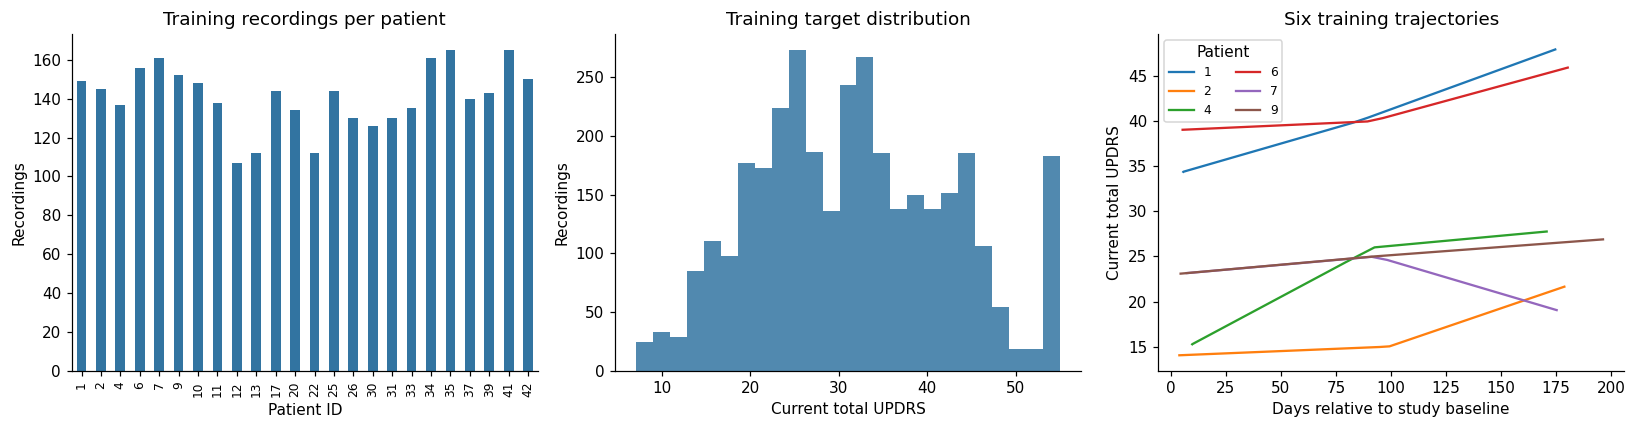

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train.groupby(GROUP).size().sort_index().plot.bar(ax=axes[0], color="#3274A1")
axes[0].set(title="Training recordings per patient", xlabel="Patient ID", ylabel="Recordings")
axes[0].tick_params(axis="x", labelsize=8)
axes[1].hist(train[TARGET], bins=25, color="#3274A1", alpha=.85)
axes[1].set(title="Training target distribution", xlabel="Current total UPDRS", ylabel="Recordings")
for patient in sorted(train_ids)[:6]:
    part = train[train[GROUP] == patient].sort_values("test_time")
    axes[2].plot(part["test_time"], part[TARGET], linewidth=1.5, label=str(patient))
axes[2].set(title="Six training trajectories", xlabel="Days relative to study baseline", ylabel="Current total UPDRS")
axes[2].legend(title="Patient", ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## Predeclare model selection and metrics

Four-fold `GroupKFold` separates patients inside the training partition. Compare a median dummy predictor, three Ridge penalties, and two modest nonlinear models. Imputation and scaling are fitted within each fold. Histogram gradient boosting disables its default internal early stopping so it cannot create a row-based validation split.

Select the candidate with lowest **mean fold patient-macro MAE**: compute MAE for each validation patient, then give every patient equal weight. Row MAE, RMSE, and R² remain useful secondary summaries; R² can legitimately be negative. Fold standard deviations measure variation across these four folds, not a confidence interval. No holdout feedback changes this grid.

In [6]:
def metric_bundle(y_true, y_pred, groups):
    y_true, y_pred, groups = np.asarray(y_true), np.asarray(y_pred), np.asarray(groups)
    errors = pd.DataFrame({"patient": groups, "abs_error": np.abs(y_true-y_pred)})
    return {"patient_macro_MAE": float(errors.groupby("patient")["abs_error"].mean().mean()),
            "row_MAE": float(mean_absolute_error(y_true, y_pred)),
            "row_RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "row_R2": float(r2_score(y_true, y_pred))}

def ridge_pipeline(alpha):
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler()), ("model", Ridge(alpha=alpha))])

def boosting_pipeline(leaves):
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("model", HistGradientBoostingRegressor(max_iter=180,
                      learning_rate=.05, max_leaf_nodes=leaves, min_samples_leaf=25,
                      l2_regularization=1.0, early_stopping=False, random_state=SEED))])

candidates = {"Dummy median": Pipeline([("impute", SimpleImputer(strategy="median")),
                                       ("model", DummyRegressor(strategy="median"))]),
              "Ridge alpha=1": ridge_pipeline(1),
              "Ridge alpha=10": ridge_pipeline(10),
              "Ridge alpha=100": ridge_pipeline(100),
              "HistGB leaves=7": boosting_pipeline(7),
              "HistGB leaves=15": boosting_pipeline(15)}
X_train, y_train, groups_train = train[FEATURES], train[TARGET], train[GROUP]
folds = list(GroupKFold(n_splits=4).split(X_train, y_train, groups_train))
for fit_rows, validation_rows in folds:
    assert set(groups_train.iloc[fit_rows]).isdisjoint(set(groups_train.iloc[validation_rows]))
print("Verified: all four CV folds have disjoint training/validation patients.")

Verified: all four CV folds have disjoint training/validation patients.


In [7]:
cv_records = []
with threadpool_limits(limits=1):
    for name, estimator in candidates.items():
        for fold, (fit_rows, validation_rows) in enumerate(folds, start=1):
            fitted = clone(estimator).fit(X_train.iloc[fit_rows], y_train.iloc[fit_rows])
            prediction = fitted.predict(X_train.iloc[validation_rows])
            cv_records.append({"candidate": name, "fold": fold,
                               **metric_bundle(y_train.iloc[validation_rows], prediction,
                                               groups_train.iloc[validation_rows])})
cv_results = pd.DataFrame(cv_records)
leaderboard = cv_results.groupby("candidate").agg(
    patient_MAE_mean=("patient_macro_MAE", "mean"),
    patient_MAE_fold_sd=("patient_macro_MAE", "std"),
    row_MAE_mean=("row_MAE", "mean"), row_RMSE_mean=("row_RMSE", "mean"),
    row_R2_mean=("row_R2", "mean")).sort_values("patient_MAE_mean", kind="stable")
selected_name = str(leaderboard.index[0])
display(leaderboard.round(3))
print("Selected using training CV only:", selected_name)

,patient_MAE_mean,patient_MAE_fold_sd,row_MAE_mean,row_RMSE_mean,row_R2_mean
candidate,,,,,
Dummy median,10.267,3.103,10.432,11.718,-1.889
Ridge alpha=100,12.215,2.519,12.213,14.011,-4.530
Ridge alpha=10,12.435,2.252,12.404,14.526,-4.876
Ridge alpha=1,12.460,2.121,12.422,14.661,-4.951
HistGB leaves=15,13.034,3.409,13.274,15.672,-3.726
HistGB leaves=7,13.112,3.052,13.372,15.793,-3.932


Selected using training CV only: Dummy median


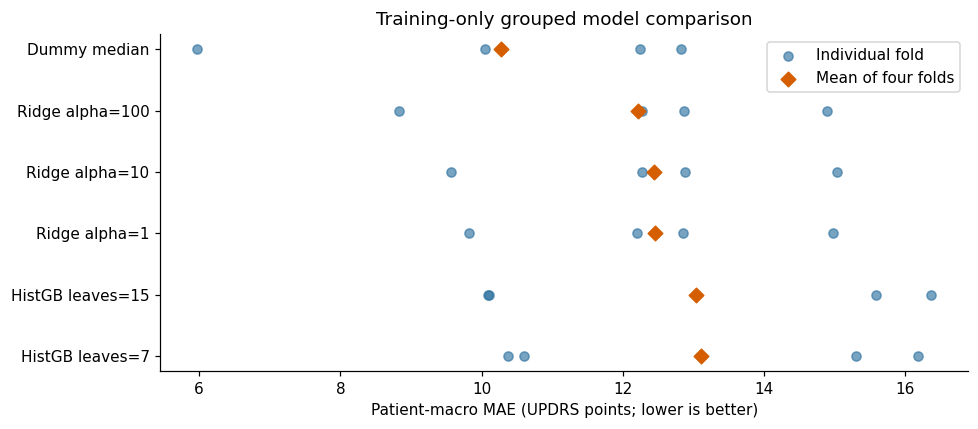

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ordered_names = leaderboard.index.tolist()
for i, name in enumerate(ordered_names):
    values = cv_results.loc[cv_results["candidate"] == name, "patient_macro_MAE"].to_numpy()
    ax.scatter(values, np.repeat(i, len(values)), color="#3274A1", alpha=.65, label="Individual fold" if i == 0 else None)
ax.scatter(leaderboard["patient_MAE_mean"], range(len(ordered_names)),
           color="#D55E00", marker="D", s=45, label="Mean of four folds")
ax.set(yticks=range(len(ordered_names)), yticklabels=ordered_names,
       xlabel="Patient-macro MAE (UPDRS points; lower is better)", title="Training-only grouped model comparison")
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
plt.show()

## Freeze the choice, then evaluate unseen patients

Refit the selected candidate on the 24 training patients only. The median baseline uses the same training partition. The nine calibration patients are reserved for interval construction and do not enlarge the fit. Evaluate the nine final test patients once, with these frozen predictions, then use those same predictions for uncertainty and failure analysis. A strong CV result does not guarantee a favourable holdout result.

In [9]:
with threadpool_limits(limits=1):
    selected_model = clone(candidates[selected_name]).fit(X_train, y_train)
    baseline_model = clone(candidates["Dummy median"]).fit(X_train, y_train)
    calibration_predictions = selected_model.predict(calibration[FEATURES])
    test_predictions = selected_model.predict(test[FEATURES])
    baseline_predictions = baseline_model.predict(test[FEATURES])
assert np.isfinite(test_predictions).all() and len(test_predictions) == len(test)
test_metrics = pd.DataFrame({
    "Selected: " + selected_name: metric_bundle(test[TARGET], test_predictions, test[GROUP]),
    "Dummy median": metric_bundle(test[TARGET], baseline_predictions, test[GROUP])
}).T
display(test_metrics.round(3))
print("Holdout patients:", test[GROUP].nunique(), "recordings:", len(test))
print("Patient-macro MAE improvement over dummy:",
      round(test_metrics.iloc[1]["patient_macro_MAE"]-test_metrics.iloc[0]["patient_macro_MAE"], 3))

,patient_macro_MAE,row_MAE,row_RMSE,row_R2
Selected: Dummy median,8.506,8.079,9.963,-0.381
Dummy median,8.506,8.079,9.963,-0.381


Holdout patients: 9 recordings: 1280
Patient-macro MAE improvement over dummy: 0.0


## Quantify uncertainty at the patient level

Resample the **nine test patients** with replacement, taking every recording for each sampled patient. Duplicate draws keep their multiplicity. The same draws compare the selected model and baseline, so the improvement interval is paired. Positive improvement means lower error than the baseline.

The 2,000 percentile bootstrap draws give a rough 95% interval conditional on this fitted model and this split. They describe test-patient sampling uncertainty, exclude training and selection variability, and are unstable with only nine patients. A row bootstrap would overstate the independent sample size.

In [10]:
holdout = test[[GROUP, "test_time", TARGET]].copy().reset_index(drop=True)
holdout["prediction"] = test_predictions
holdout["baseline_prediction"] = baseline_predictions
holdout["residual"] = holdout[TARGET] - holdout["prediction"]
holdout["abs_error"] = holdout["residual"].abs()
holdout["baseline_abs_error"] = (holdout[TARGET]-holdout["baseline_prediction"]).abs()
holdout_ids = np.sort(holdout[GROUP].unique())
patient_indices = {patient: np.flatnonzero(holdout[GROUP].to_numpy() == patient) for patient in holdout_ids}
patient_mae = holdout.groupby(GROUP)[["abs_error", "baseline_abs_error"]].mean().reindex(holdout_ids)
y_test_array = holdout[TARGET].to_numpy()
selected_array = holdout["prediction"].to_numpy()
baseline_array = holdout["baseline_prediction"].to_numpy()
rng = np.random.default_rng(SEED + 1)
bootstrap_records = []
for _ in range(BOOTSTRAP_REPEATS):
    sampled_positions = rng.integers(0, len(holdout_ids), size=len(holdout_ids))
    row_positions = np.concatenate([patient_indices[holdout_ids[position]] for position in sampled_positions])
    selected_errors = y_test_array[row_positions]-selected_array[row_positions]
    baseline_errors = y_test_array[row_positions]-baseline_array[row_positions]
    macro_mae = patient_mae["abs_error"].iloc[sampled_positions].mean()
    baseline_macro_mae = patient_mae["baseline_abs_error"].iloc[sampled_positions].mean()
    bootstrap_records.append({"patient_macro_MAE": macro_mae,
        "row_MAE": np.mean(np.abs(selected_errors)),
        "row_RMSE": np.sqrt(np.mean(selected_errors**2)),
        "patient_MAE_improvement": baseline_macro_mae-macro_mae,
        "row_MAE_improvement": np.mean(np.abs(baseline_errors))-np.mean(np.abs(selected_errors))})
bootstrap = pd.DataFrame(bootstrap_records)
bootstrap_intervals = bootstrap.quantile([.025, .975]).T.rename(columns={.025: "95% lower", .975: "95% upper"})
point_estimates = test_metrics.iloc[0][["patient_macro_MAE", "row_MAE", "row_RMSE"]].to_dict()
point_estimates["patient_MAE_improvement"] = test_metrics.iloc[1]["patient_macro_MAE"]-test_metrics.iloc[0]["patient_macro_MAE"]
point_estimates["row_MAE_improvement"] = test_metrics.iloc[1]["row_MAE"]-test_metrics.iloc[0]["row_MAE"]
bootstrap_intervals.insert(0, "point_estimate", pd.Series(point_estimates))
display(bootstrap_intervals.round(3))

,point_estimate,95% lower,95% upper
patient_macro_MAE,8.506,4.918,12.577
row_MAE,8.079,4.729,11.949
row_RMSE,9.963,6.360,13.243
patient_MAE_improvement,0.000,0.000,0.000
row_MAE_improvement,0.000,0.000,0.000


## Inspect failure, not just average error

Each colour below represents one unseen patient. Persistent offsets can dominate performance even when within-patient curves appear smooth. The residual sign is **observed minus predicted**: positive values indicate underprediction. These plots are post-evaluation diagnostics, not a basis for retraining against the test set.

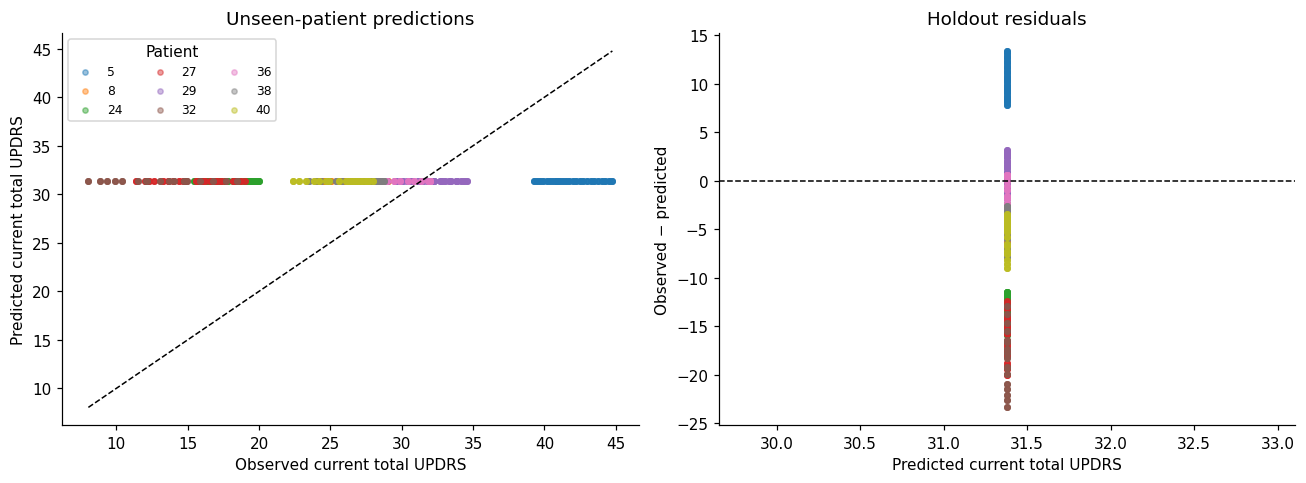

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.get_cmap("tab10").colors
for i, patient in enumerate(holdout_ids):
    part = holdout[holdout[GROUP] == patient]
    axes[0].scatter(part[TARGET], part["prediction"], s=12, alpha=.45, color=colors[i], label=str(patient))
    axes[1].scatter(part["prediction"], part["residual"], s=12, alpha=.45, color=colors[i])
low = min(holdout[TARGET].min(), holdout["prediction"].min())
high = max(holdout[TARGET].max(), holdout["prediction"].max())
axes[0].plot([low, high], [low, high], "k--", linewidth=1)
axes[0].set(title="Unseen-patient predictions", xlabel="Observed current total UPDRS", ylabel="Predicted current total UPDRS")
axes[0].legend(title="Patient", ncol=3, fontsize=8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(title="Holdout residuals", xlabel="Predicted current total UPDRS", ylabel="Observed − predicted")
fig.tight_layout()
plt.show()

,recordings,observed_mean,predicted_mean,MAE,baseline_MAE,bias,max_absolute_error,MAE_improvement
subject#,,,,,,,,
32,101,13.039,31.38,18.341,18.341,-18.341,23.344,0.0
27,129,15.434,31.38,15.946,15.946,-15.946,20.035,0.0
24,156,18.276,31.38,13.104,13.104,-13.104,15.932,0.0
5,156,41.854,31.38,10.474,10.474,10.474,13.381,0.0
8,150,25.887,31.38,5.493,5.493,-5.493,7.287,0.0
40,142,25.954,31.38,5.426,5.426,-5.426,9.031,0.0
38,149,26.809,31.38,4.571,4.571,-4.571,7.867,0.0
29,168,31.506,31.38,1.656,1.656,0.126,3.358,0.0
36,129,30.424,31.38,1.545,1.545,-0.956,4.818,0.0


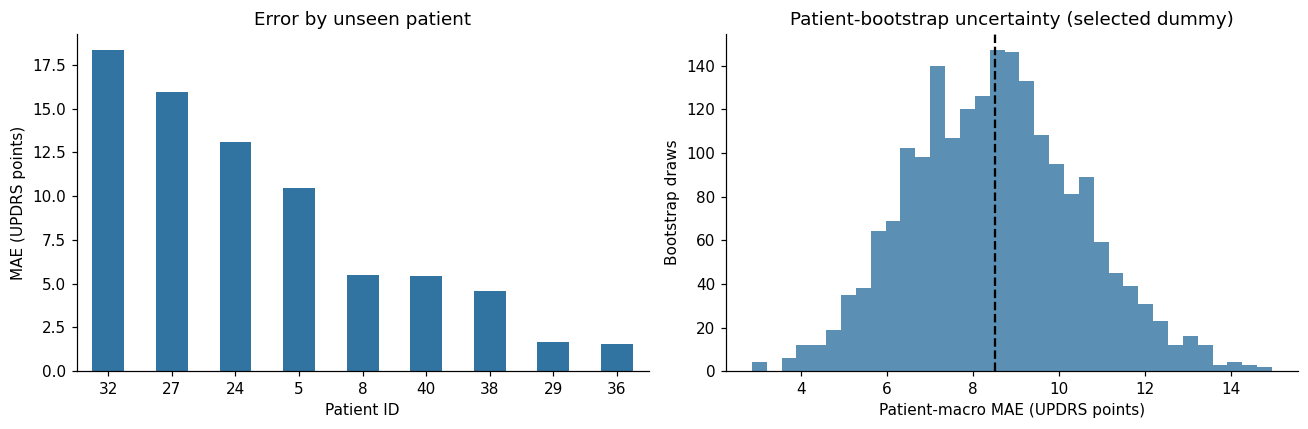

In [12]:
subject_errors = holdout.groupby(GROUP).agg(
    recordings=(TARGET, "size"), observed_mean=(TARGET, "mean"),
    predicted_mean=("prediction", "mean"), MAE=("abs_error", "mean"),
    baseline_MAE=("baseline_abs_error", "mean"), bias=("residual", "mean"),
    max_absolute_error=("abs_error", "max"))
subject_errors["MAE_improvement"] = subject_errors["baseline_MAE"]-subject_errors["MAE"]
subject_errors = subject_errors.sort_values("MAE", ascending=False)
display(subject_errors.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if selected_name == "Dummy median":
    subject_errors[["MAE"]].plot.bar(ax=axes[0], color=["#3274A1"], legend=False)
else:
    subject_errors[["MAE", "baseline_MAE"]].plot.bar(ax=axes[0], color=["#3274A1", "#999999"])
axes[0].set(title="Error by unseen patient", xlabel="Patient ID", ylabel="MAE (UPDRS points)")
axes[0].tick_params(axis="x", rotation=0)
if selected_name == "Dummy median":
    axes[1].hist(bootstrap["patient_macro_MAE"], bins=35, color="#3274A1", alpha=.8)
    axes[1].axvline(test_metrics.iloc[0]["patient_macro_MAE"], color="black", linestyle="--")
    axes[1].set(title="Patient-bootstrap uncertainty (selected dummy)",
                xlabel="Patient-macro MAE (UPDRS points)", ylabel="Bootstrap draws")
else:
    axes[1].hist(bootstrap["patient_MAE_improvement"], bins=35, color="#3274A1", alpha=.8)
    axes[1].axvline(0, color="black", linestyle="--")
    axes[1].set(title="Paired patient-bootstrap improvement", xlabel="Dummy MAE − selected MAE", ylabel="Bootstrap draws")
fig.tight_layout()
plt.show()

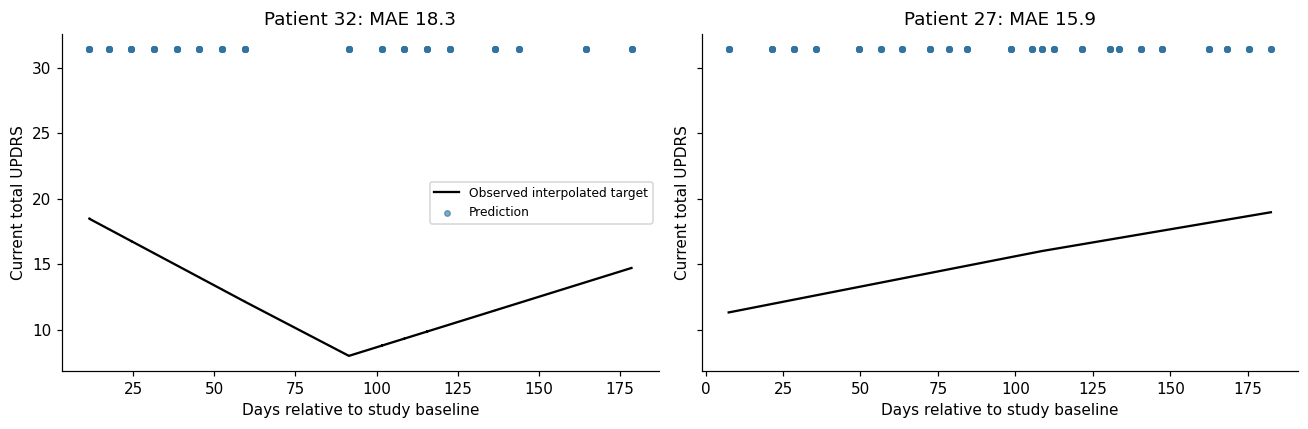

In [13]:
worst_patients = subject_errors.index[:2]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, patient in zip(axes, worst_patients):
    part = holdout[holdout[GROUP] == patient].sort_values("test_time")
    ax.plot(part["test_time"], part[TARGET], color="black", label="Observed interpolated target")
    ax.scatter(part["test_time"], part["prediction"], s=13, alpha=.6, color="#3274A1", label="Prediction")
    ax.set(title=f"Patient {patient}: MAE {subject_errors.loc[patient, 'MAE']:.1f}",
           xlabel="Days relative to study baseline", ylabel="Current total UPDRS")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Exploratory intervals: calibrate patients, not thousands of rows

Use one calibration score per patient: their **maximum absolute error across all recordings**. For nominal 90% simultaneous coverage, the split-conformal rank is `ceil((m + 1) × 0.90)`, where `m` is the number of calibration patients. With just nine patients the cutoff is the largest calibration score; with eight it would be infinite. A finite 95% cutoff would require at least 19 calibration patients.

Under **exchangeable patient recording clusters and a comparable recording process**, this construction targets coverage of every recording in one new patient's cluster. Patient cohorts, visit schedules, and clinical processes may violate those assumptions. It offers no unconditional clinical or distribution-shift guarantee. Row coverage is reported only as a secondary descriptive statistic. Broad intervals and coarse patient coverage are expected with this small cohort; the experiment demonstrates the cost of respecting dependence.

,value
nominal_patient_cluster_coverage,0.90
calibration_patients,9.00
order_statistic_rank,9.00
radius_UPDRS_points,24.38
interval_width,48.76
test_row_coverage_descriptive,1.00
test_all_recordings_patient_coverage,1.00
fully_covered_test_patients,9.00
test_patients,9.00


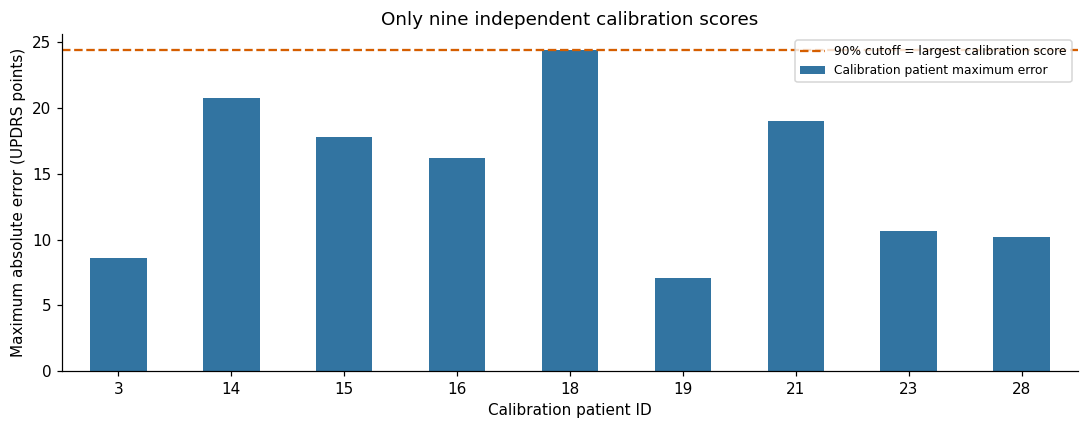

In [14]:
ALPHA = .10
calibration_errors = pd.DataFrame({GROUP: calibration[GROUP].to_numpy(),
    "abs_error": np.abs(calibration[TARGET].to_numpy()-calibration_predictions)})
calibration_scores = calibration_errors.groupby(GROUP)["abs_error"].max().sort_values()
m = len(calibration_scores)
rank = math.ceil((m + 1) * (1-ALPHA))
interval_radius = float(calibration_scores.iloc[rank-1]) if rank <= m else float("inf")
holdout["interval_lower"] = holdout["prediction"]-interval_radius
holdout["interval_upper"] = holdout["prediction"]+interval_radius
holdout["covered"] = holdout[TARGET].between(holdout["interval_lower"], holdout["interval_upper"])
patient_coverage = holdout.groupby(GROUP)["covered"].all()
interval_summary = pd.Series({"nominal_patient_cluster_coverage": 1-ALPHA,
    "calibration_patients": m, "order_statistic_rank": rank,
    "radius_UPDRS_points": interval_radius, "interval_width": 2*interval_radius,
    "test_row_coverage_descriptive": holdout["covered"].mean(),
    "test_all_recordings_patient_coverage": patient_coverage.mean(),
    "fully_covered_test_patients": int(patient_coverage.sum()),
    "test_patients": len(patient_coverage)})
assert m == 9 and rank == 9 and np.isfinite(interval_radius)
display(interval_summary.to_frame("value").round(3))
fig, ax = plt.subplots(figsize=(10, 4))
calibration_scores.sort_index().plot.bar(ax=ax, color="#3274A1", label="Calibration patient maximum error")
ax.axhline(interval_radius, color="#D55E00", linestyle="--", label="90% cutoff = largest calibration score")
ax.set(title="Only nine independent calibration scores", xlabel="Calibration patient ID", ylabel="Maximum absolute error (UPDRS points)")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## What the results support

The printed findings below derive from this execution. Interpret performance in UPDRS points and compare it with the simple baseline. Patient-macro MAE prevents a patient with more recordings from dominating the summary. For distinct models, a bootstrap improvement interval crossing zero leaves superiority of either model unresolved for this small holdout. If grouped CV selects the dummy itself, the paired improvement is exactly zero by construction and offers no comparison between distinct predictors. Even an interval above zero is conditional on this split and does not establish clinical usefulness.

The model predicts current interpolated severity in unseen members of this research cohort. It does not establish future progression prediction, diagnosis, treatment response, clinical agreement, fairness across demographic groups, or transportability to another microphone or population. Age and sex may proxy cohort structure; the 42-person sample is too small to support reliable subgroup claims. Voice features are correlated, and large patient-specific offsets need investigation in a larger external cohort.

The next defensible study would predefine an external cohort and recording protocol, obtain independently assessed clinical outcomes, and evaluate patient-level calibration and model stability. Revising hyperparameters after inspecting this holdout would require a new final test cohort.

In [15]:
selected_mae = float(test_metrics.iloc[0]["patient_macro_MAE"])
baseline_mae = float(test_metrics.iloc[1]["patient_macro_MAE"])
improvement_limits = bootstrap_intervals.loc["patient_MAE_improvement", ["95% lower", "95% upper"]]
print(f"Finding: {selected_name}; patient-macro test MAE {selected_mae:.2f} UPDRS points "
      f"versus dummy {baseline_mae:.2f}.")
print(f"Row MAE {test_metrics.iloc[0]['row_MAE']:.2f}; RMSE {test_metrics.iloc[0]['row_RMSE']:.2f}; "
      f"R² {test_metrics.iloc[0]['row_R2']:.3f}.")
print(f"Paired patient-MAE improvement 95% bootstrap interval: "
      f"[{improvement_limits.iloc[0]:.2f}, {improvement_limits.iloc[1]:.2f}] points.")
if selected_name == "Dummy median":
    print("No learned candidate beat the dummy under the predefined grouped-CV selection criterion.")
    print("The selected predictor ignores voice measurements; this result does not demonstrate voice predictive value.")
    print("Paired improvement is exactly zero because the selected predictor is the baseline itself.")
elif improvement_limits.iloc[0] > 0:
    print("This conditional bootstrap interval favours the selected model over the dummy.")
elif improvement_limits.iloc[1] < 0:
    print("This conditional bootstrap interval favours the dummy over the selected model.")
else:
    print("This small holdout does not resolve superiority over the dummy in the bootstrap comparison.")
print(f"Patient-max interval width {2*interval_radius:.1f} points; all-recordings coverage "
      f"{int(patient_coverage.sum())}/{len(patient_coverage)} unseen patients.")

Finding: Dummy median; patient-macro test MAE 8.51 UPDRS points versus dummy 8.51.
Row MAE 8.08; RMSE 9.96; R² -0.381.
Paired patient-MAE improvement 95% bootstrap interval: [0.00, 0.00] points.
No learned candidate beat the dummy under the predefined grouped-CV selection criterion.
The selected predictor ignores voice measurements; this result does not demonstrate voice predictive value.
Paired improvement is exactly zero because the selected predictor is the baseline itself.
Patient-max interval width 48.8 points; all-recordings coverage 9/9 unseen patients.


In [16]:
# Final experiment integrity checks: fail instead of silently reporting a broken design.
assert len(candidates) == 6 and len(cv_results) == 24
assert len(FEATURES) == 18 and {GROUP, TARGET, "motor_UPDRS", "test_time"}.isdisjoint(FEATURES)
assert sum(len(part) for part in [train, calibration, test]) == len(df)
assert all(subject_sets[i].isdisjoint(subject_sets[j]) for i in range(3) for j in range(i+1, 3))
assert set(train[GROUP]) == set(train_ids)
assert np.isfinite(test_metrics.to_numpy()).all()
assert len(bootstrap) == BOOTSTRAP_REPEATS
experiment_record = {
    "question": "Current interpolated total_UPDRS from voice, age and sex in unseen patients",
    "data_url": DATA_URL, "data_sha256": data_sha256, "seed": SEED,
    "patients": {"train": sorted(map(int, train_ids)),
                 "calibration": sorted(map(int, calibration_ids)), "test": sorted(map(int, test_ids))},
    "features": FEATURES, "selection_metric": "mean GroupKFold patient-macro MAE",
    "cv_folds": 4, "candidate_parameters": {
        name: str(estimator) for name, estimator in candidates.items()},
    "selected_model": selected_name, "test_metrics": test_metrics.to_dict(orient="index"),
    "patient_bootstrap_95pct": bootstrap_intervals.to_dict(orient="index"),
    "interval_experiment": interval_summary.to_dict(),
    "versions": {"python": platform.python_version(), "numpy": np.__version__,
                 "pandas": pd.__version__, "sklearn": sklearn.__version__}
}
print("All experiment integrity checks passed.")
print(json.dumps(experiment_record, indent=2, allow_nan=False))

All experiment integrity checks passed.
{
  "question": "Current interpolated total_UPDRS from voice, age and sex in unseen patients",
  "data_url": "https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip",
  "data_sha256": "2f82bb0ef96fa7d8d7edf4d97b89173e07c2cca7723440a64bc38918a83345df",
  "seed": 2026,
  "patients": {
    "train": [
      1,
      2,
      4,
      6,
      7,
      9,
      10,
      11,
      12,
      13,
      17,
      20,
      22,
      25,
      26,
      30,
      31,
      33,
      34,
      35,
      37,
      39,
      41,
      42
    ],
    "calibration": [
      3,
      14,
      15,
      16,
      18,
      19,
      21,
      23,
      28
    ],
    "test": [
      5,
      8,
      24,
      27,
      29,
      32,
      36,
      38,
      40
    ]
  },
  "features": [
    "age",
    "sex",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shim